## Exploring tsc_llm_rules results

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

In [85]:
import os
os.getcwd()

'c:\\Users\\chriz\\OneDrive - University of Bergen\\UIB\\Master Informatikk\\Semester 3\\TSC\\LLM_rules_for_TSC\\TSC_LLM_rules\\results\\llm_explore'

In [137]:
# load data
data = []
with open("../llm_results/SonyAIBORobotSurface1_baseline_llm_results.jsonl", 'r') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

### Boxplot

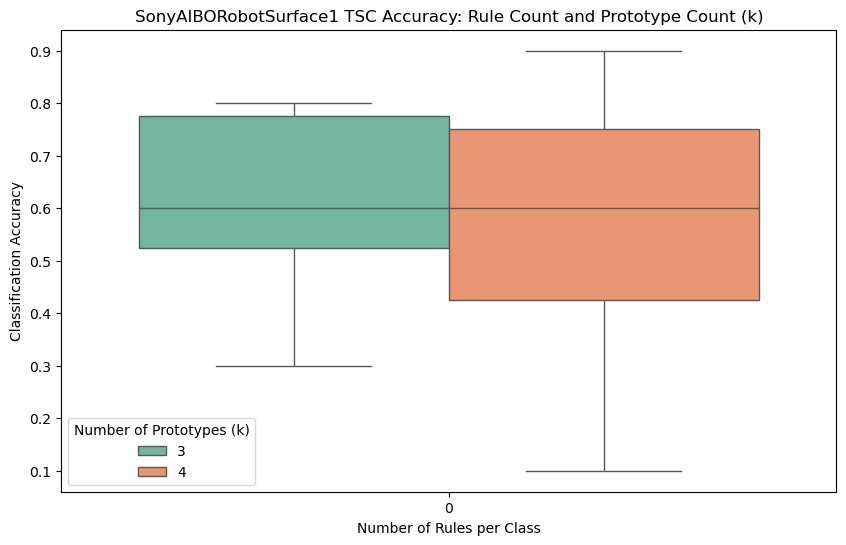

In [138]:
# accuracy vs. number of sub-rules and K (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='num_rules', y='accuracy', hue='k', palette='Set2')
plt.title('SonyAIBORobotSurface1 TSC Accuracy: Rule Count and Prototype Count (k)')
plt.xlabel('Number of Rules per Class')
plt.ylabel('Classification Accuracy')
plt.legend(title='Number of Prototypes (k)')
plt.savefig('llm_SonyAIBORobotSurface1_baseline_accuracy_boxplot.pdf', bbox_inches='tight')
plt.show()

### outlier investigation testrun 56

In [139]:
# outlier entry in k=4 and sub-rule count=3
'''

outlier = data[55] 

print(f"OUTLIER (Line 56)")
print(f"Dataset: {outlier['dataset']} | k: {outlier['k']} | Rules: {outlier['num_rules']}")

true_labels = [inst['true_label'] for inst in outlier['instance']]
pred_labels = [inst['predicted_label'] for inst in outlier['instance']]

print("\nFull Label Sequence:")
print(f"True Labels: {true_labels}")
print(f"Pred Labels: {pred_labels}")
print(f"Total Accuracy: {outlier['accuracy']}")

print("\nThe Rules Generated for this Run")
for cls, rule_text in outlier['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")
'''

'\n\noutlier = data[55] \n\nprint(f"OUTLIER (Line 56)")\nprint(f"Dataset: {outlier[\'dataset\']} | k: {outlier[\'k\']} | Rules: {outlier[\'num_rules\']}")\n\ntrue_labels = [inst[\'true_label\'] for inst in outlier[\'instance\']]\npred_labels = [inst[\'predicted_label\'] for inst in outlier[\'instance\']]\n\nprint("\nFull Label Sequence:")\nprint(f"True Labels: {true_labels}")\nprint(f"Pred Labels: {pred_labels}")\nprint(f"Total Accuracy: {outlier[\'accuracy\']}")\n\nprint("\nThe Rules Generated for this Run")\nfor cls, rule_text in outlier[\'extracted_rules\'].items():\n    print(f"\n[{cls.upper()}]:\n{rule_text}")\n'

In [140]:
'''
example1 = data[60]
print("\nThe Rules for another run")
for cls, rule_text in example1['extracted_rules'].items():
    print(f"\n[{cls.upper()}]:\n{rule_text}")
    '''

'\nexample1 = data[60]\nprint("\nThe Rules for another run")\nfor cls, rule_text in example1[\'extracted_rules\'].items():\n    print(f"\n[{cls.upper()}]:\n{rule_text}")\n    '

### looking at a specific hyperparam set
- contains the outlier

In [141]:
'''
# filter for the specific configuration
df_specific = df[(df['k'] == 4) & (df['num_rules'] == 3)].copy()

df_specific['run_id'] = range(1, len(df_specific) + 1)


plt.figure(figsize=(10, 6))
sns.stripplot(data=df_specific, x='run_id', y='accuracy', size=10, color="royalblue", alpha=0.7)
plt.axhline(df_specific['accuracy'].mean(), color='red', linestyle='--', label=f"Mean Acc: {df_specific['accuracy'].mean():.2f}")
plt.title('Performance Consistency for k=4, Rule Count=4 (10 Independent Runs)')
plt.xlabel('Run Number')
plt.ylabel('Accuracy')
plt.ylim(-0.05, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()


plt.tight_layout()
plt.savefig('llm_k4_rules3_consistency.pdf')
plt.show()
'''

'\n# filter for the specific configuration\ndf_specific = df[(df[\'k\'] == 4) & (df[\'num_rules\'] == 3)].copy()\n\ndf_specific[\'run_id\'] = range(1, len(df_specific) + 1)\n\n\nplt.figure(figsize=(10, 6))\nsns.stripplot(data=df_specific, x=\'run_id\', y=\'accuracy\', size=10, color="royalblue", alpha=0.7)\nplt.axhline(df_specific[\'accuracy\'].mean(), color=\'red\', linestyle=\'--\', label=f"Mean Acc: {df_specific[\'accuracy\'].mean():.2f}")\nplt.title(\'Performance Consistency for k=4, Rule Count=4 (10 Independent Runs)\')\nplt.xlabel(\'Run Number\')\nplt.ylabel(\'Accuracy\')\nplt.ylim(-0.05, 1.05)\nplt.grid(axis=\'y\', linestyle=\'--\', alpha=0.7)\nplt.legend()\n\n\nplt.tight_layout()\nplt.savefig(\'llm_k4_rules3_consistency.pdf\')\nplt.show()\n'

### tables

In [142]:
### accuracy rules and k

accuracy_table = df.pivot_table(
    index='k', 
    columns='num_rules', 
    values='accuracy', 
    aggfunc='mean'
)

print("Average Accuracy: k (rows) vs. Number of Rules (columns)")
display(accuracy_table.style.background_gradient(cmap='RdYlGn', axis=None).format("{:.2%}"))

Average Accuracy: k (rows) vs. Number of Rules (columns)


num_rules,0
k,
3,61.00%
4,56.00%


In [143]:
### accuracy by k

k_summary = df.groupby('k')['accuracy'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
k_summary.columns = ['k (Prototypes)', 'Mean Accuracy', 'N (Runs)']

print("Summary: Performance by Prototype Count")
display(k_summary.style.format({'Mean Accuracy': '{:.2%}'}))

Summary: Performance by Prototype Count


,k (Prototypes),Mean Accuracy,N (Runs)
0,3,61.00%,10
1,4,56.00%,10


In [144]:
### accuracy by number of rules

rules_summary = df.groupby('num_rules')['accuracy'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
rules_summary.columns = ['Sub-rule Count', 'Mean Accuracy', 'N (Runs)']

print("Summary: Performance by Rule Complexity")
display(rules_summary.style.format({'Mean Accuracy': '{:.2%}'}))

Summary: Performance by Rule Complexity


,Sub-rule Count,Mean Accuracy,N (Runs)
0,0,58.50%,20
